# Chapter 5 Homework Code

In [ ]:
import numpy as np
import statsmodels .api as sm
from ISLP import load_data
from ISLP.models import ( ModelSpec as MS, summarize, poly)
from sklearn.model_selection import train_test_split
from sklearn.model_selection import \
(cross_validate ,
KFold ,
ShuffleSplit )
from functools import partial
from sklearn.base import clone
from ISLP.models import sklearn_sm
import matplotlib.pyplot as plt
import pandas as pd
from functools import partial
from sklearn. decomposition import PCA

from ISLP.models import \
                (Stepwise ,
                sklearn_selected ,
                sklearn_selection_path)



In [197]:
def evalMSE(terms, response, train, test):
    
    mm = MS(terms)
    
    X_train = mm.fit_transform (train)
    y_train = train[response]
    X_test = mm.transform(test)
    y_test = test[response]

    results = sm.OLS(y_train, X_train).fit()
    test_pred = results.predict(X_test)
    return np.mean(( y_test - test_pred)**2)

# Question 5 Section 5.4

In Chapter 4, we used logistic regression to predict the probability of
default using income and balance on the Default data set. We will
now estimate the test error of this logistic regression model using the
validation set approach. Do not forget to set a random seed before
beginning your analysis.

a) Fit a logistic regression model that uses income and balance to predict default.

In [198]:
default_df = pd.read_csv('../Homework_Data/Default.csv')

In [199]:
#changing the text based columns to numerical
default_df['student'] = (default_df['student'] == 'Yes').astype(int)
default_df['default'] = (default_df['default'] == 'Yes').astype(int)

In [200]:
allvars = ['income', 'balance']
design = MS(allvars)
X = design.fit_transform(default_df)
y = default_df['default']
glm = sm.GLM(y,
             X,
            family=sm. families . Binomial ())

results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,-11.540500,0.435000,-26.544,0.0
income,0.000021,0.000005,4.174,0.0
balance,0.005600,0.000000,24.835,0.0


b) Using the validation set approach, estimate the test error of this
model. In order to do this, you must perform the following steps:

i. Split the sample set into a training set and a validation set.

ii. Fit a multiple logistic regression model using only the train-
ing observations.

iii. Obtain a prediction of default status for each individual in
the validation set by computing the posterior probability of
default for that individual, and classifying the individual to
the default category if the posterior probability is greater
than 0.5.

iv. Compute the validation set error, which is the fraction of
the observations in the validation set that are misclassified.

In [201]:
features_df = default_df[allvars]
response_df = default_df['default']

#i) splitting the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(features_df, response_df, test_size=0.2)

#ii) creating the model
design = MS(allvars)
x_train = design.fit_transform(X_train)
glm = sm.GLM(y_train,
             x_train,
            family=sm.families.Binomial())

results = glm.fit()
print(summarize(results))

#iii) evaluating the model
x_test = design.fit_transform(X_test)
test_pred_prob = results.predict(x_test)
test_pred_class = (test_pred_prob > 0.5).astype(int)

#iv) validation set error
misclassified = ((test_pred_class - y_test) != 0).sum()

test_error = misclassified/len(y_test)

print(test_error)


                coef   std err       z  P>|z|
intercept -11.220700  0.477000 -23.525  0.000
income      0.000017  0.000006   3.018  0.003
balance     0.005500  0.000000  21.968  0.000
0.027


In [202]:
def main_fit(features_df, response_df, allvars, test_split, random_state = 42):

    #i) splitting the data into training and testing
    X_train, X_test, y_train, y_test = train_test_split(features_df, response_df, test_size=test_split, random_state= random_state)

    #ii) creating the model
    design = MS(allvars)
    x_train = design.fit_transform(X_train)
    glm = sm.GLM(y_train,
                x_train,
                family=sm.families.Binomial())

    results = glm.fit()
    #print(summarize(results))

    #iii) evaluating the model
    x_test = design.fit_transform(X_test)
    test_pred_prob = results.predict(x_test)
    test_pred_class = (test_pred_prob > 0.5).astype(int)

    #iv) validation set error
    misclassified = ((test_pred_class - y_test) != 0).sum()

    test_error = misclassified/len(y_test)

    return test_error, results

c) Repeat the process in (b) three times, using three different splits
of the observations into a training set and a validation set. Comment on the results obtained.

In [203]:
test_split = [0.2, 0.5, 0.7]

for split in test_split:
    
    print(main_fit(features_df, response_df, allvars, split))

(np.float64(0.0305), <statsmodels.genmod.generalized_linear_model.GLMResultsWrapper object at 0x17953f2c0>)
(np.float64(0.0258), <statsmodels.genmod.generalized_linear_model.GLMResultsWrapper object at 0x179664140>)
(np.float64(0.026714285714285715), <statsmodels.genmod.generalized_linear_model.GLMResultsWrapper object at 0x1796646b0>)


d) Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable
for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a
dummy variable for student leads to a reduction in the test error rate.

In [204]:
new_features = default_df[['student', 'balance', 'income']]
new_response = default_df['default']

In [205]:
error, default_result = main_fit(new_features, new_response, ['student', 'balance', 'income'], 0.2)

# Question 7 Section 5.4

In Sections 5.1.2 and 5.1.3, we saw that the cross_validate() function
can be used in order to compute the LOOCV test error estimate.
Alternatively, one could compute those quantities using just sm.GLM()
and the predict() method of the fitted model within a for loop. You
will now take this approach in order to compute the LOOCV error
for a simple logistic regression model on the Weekly data set. Recall
that in the context of classification problems, the LOOCV error is
given in (5.4).

a) Fit a logistic regression model that predicts Direction using Lag1
and Lag2.

In [206]:
weekly_df = pd.read_csv('../Homework_Data/Weekly.csv')

In [207]:
#convert the 'Direction' column to numerical
weekly_df['Direction'] = (weekly_df['Direction'] == 'Up').astype(int)

In [208]:
print(test_error)

0.027


b) Fit a logistic regression model that predicts Direction using Lag1
and Lag2 using all but the first observation.

In [209]:
feature_lags12_new = weekly_df[['Lag1', 'Lag2']].iloc[1:]
response_df12_new = weekly_df['Direction'].iloc[1:]

test_error_new, result_lag12_new = main_fit(feature_lags12_new, response_df12_new, ['Lag1', 'Lag2'], 0.2)
print(test_error)

0.027


c) Use the model from (b) to predict the direction of the first observation. You can do this by predicting that the first observation
will go up if P (Direction = "Up"|Lag1, Lag2) > 0.5. Was this observation correctly classified?

d) Write a for loop from i = 1 to i= n, where n is the number of
observations in the data set, that performs each of the following
steps:

- i. Fit a logistic regression model using all but the ith observation to predict Direction using Lag1 and Lag2.
- ii. Compute the posterior probability of the market moving up for the ith observation.
- iii. Use the posterior probability for the ith observation in order to predict whether or not the market moves up.
- iv. Determine whether or not an error was made in predicting the direction for the ith observation. If an error was made, then indicate this as a 1, and otherwise indicate it as a 0.

e) Take the average of the n numbers obtained in (d)iv in order to
obtain the LOOCV estimate for the test error. Comment on the
results.

# Question 8 Section 5.4

a) Generate a simulated data set as follows: 

In this data set, what is n and what is p? Write out the model
used to generate the data in equation form.

In [210]:
# generate Random data
rng = np.random.default_rng(1)
x = rng.normal(size =100)
y = x - 2 * x**2 + rng.normal(size =100)

b) Create a scatterplot of X against Y . Comment on what you find

In [211]:
plt.figure(figsize = (10, 5))
plt.scatter(x, y)
plt.xlabel('X-Data')
plt.ylabel('Y-Data')
plt.show()

KeyboardInterrupt: 

c) Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:

- i. Y= β0 + β1X + ϵ
- ii. Y= β0 + β1X + β2X2 + ϵ
- iii. Y= β0 + β1X + β2X2 + β3X3 + ϵ
- iv. Y= β0 + β1X + β2X2 + β3X3 + β4X4 + ϵ.

Note you may find it helpful to use the data.frame() function
to create a single data set containing both X and Y.

d) Repeat (c) using another random seed, and report your results.
Are your results the same as what you got in (c)? Why?

e) Which of the models in (c) had the smallest LOOCV error? Is
this what you expected? Explain your answer.

f) Comment on the statistical significance of the coefficient esti-
mates that results from fitting each of the models in (c) using
least squares. Do these results agree with the conclusions drawn
based on the cross-validation results?

# Question 9 Section 6.6

In this exercise, we will predict the number of applications received
using the other variables in the College data set.

a) Split the data set into a training set and a test set.

b) Fit a linear model using least squares on the training set, and
report the test error obtained.

c) Fit a ridge regression model on the training set, with λ chosen
by cross-validation. Report the test error obtained.

d) Fit a lasso model on the training set, with λ chosen by cross-
validation. Report the test error obtained, along with the num-
ber of non-zero coefficient estimates.

e) Fit a PCR model on the training set, with M chosen by cross-
validation. Report the test error obtained, along with the value
of M selected by cross-validation.

g) Comment on the results obtained. How accurately can we pre-
dict the number of college applications received? Is there much
difference among the test errors resulting from these five ap-
proaches?

# Question 10 Section 6.6

We have seen that as the number of features used in a model increases,
the training error will necessarily decrease, but the test error may not.
We will now explore this in a simulated data set.

a) Generate a data set with p = 20 features, n = 1,000 observations, and an associated quantitative response vector generated
according to the model

Y= Xβ + ϵ,

where β has some elements that are exactly equal to zero.

In [192]:
np.random.seed(145423223)
#genertaing random data X goes form 0-100
X = np.random.uniform(0, 100, size = (1000, 20))
#getting 20 random betas
Betas = np.random.normal(loc = 0, scale = 10, size = 20)

#grabbing random index to turn the beta to be 0
rand_idx_to_turn_zero = np.random.choice(np.arange(0, 20), size=5, replace=False)
Betas[rand_idx_to_turn_zero] = 0

#computing the Y values and adding in some noise
Y = np.dot(X, Betas).T + np.random.normal(loc = 0, scale = 1, size = 1000)

b) Split your data set into a training set containing 100 observations
and a test set containing 900 observations.

In [193]:
#making DataFrames
columns = [f'Feature_{i}' for i in range(1, 21)]
X_df = pd.DataFrame(X, columns = columns, index = range(1, 1001))
Y_df = pd.DataFrame(Y, columns = ['Y'])

In [194]:
test_train_split = ShuffleSplit(n_splits = 1, test_size = 0.1, random_state = 42)
train_idx, test_idx = next(test_train_split.split(X))
X_train, X_test = X_df.iloc[train_idx], X_df.iloc[test_idx]
Y_train, Y_test = Y_df.iloc[train_idx], Y_df.iloc[test_idx]

c) Perform best subset selection on the training set, and plot the
training set MSE associated with the best model of each size.

In [214]:
import numpy as np
import pandas as pd
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Split data into training and test sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X_df, Y_df, test_size=0.1, random_state=42)

def forward_stepwise_selection(X, Y):
    
    selected_features = []
    remaining_features = list(X.columns)
    best_models = []
    
    for k in range(1, len(X.columns) + 1):
        best_mse = np.inf
        best_feature = None
        best_model = None
        
        for feature in remaining_features:
            # Try adding one feature at a time
            features_to_try = selected_features + [feature]
            X_subset = sm.add_constant(X[features_to_try])  # Add intercept
            
            model = sm.OLS(Y, X_subset).fit()
            mse = mean_squared_error(Y, model.fittedvalues)
            
            if mse < best_mse:
                best_mse = mse
                best_feature = feature
                best_model = model
        
        # Add the best feature and update lists
        if best_feature:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            best_models.append((list(selected_features), best_mse, best_model))
    
    return best_models

# Run forward stepwise selection
best_models_fs = forward_stepwise_selection(X_train, Y_train.values)

# Extract number of features and training MSEs
num_features_fs = list(range(1, len(X_train.columns) + 1))
train_mse_fs = [mse for _, mse, _ in best_models_fs]

d) Plot the test set MSE associated with the best model of each
size.

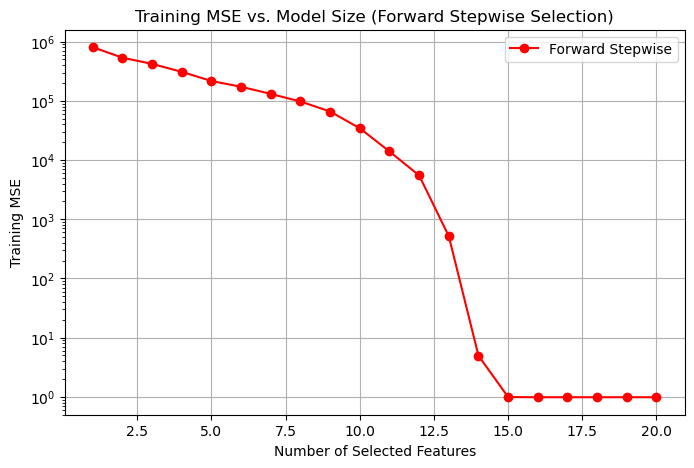

In [216]:
# Plot training MSE vs. number of features
plt.figure(figsize=(8, 5))
plt.plot(num_features_fs, train_mse_fs, marker='o', linestyle='-', color='r', label="Forward Stepwise")
plt.xlabel("Number of Selected Features")
plt.ylabel("Training MSE")
plt.title("Training MSE vs. Model Size (Forward Stepwise Selection)")
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

e) For which model size does the test set MSE take on its minimum
value? Comment on your results. If it takes on its minimum value
for a model containing only an intercept or a model containing
all of the features, then play around with the way that you are
generating the data in (a) until you come up with a scenario in
which the test set MSE is minimized for an intermediate model
size.


I found that the best model occurs when the model size has 15 features it seems like after that there is no real gain in information by the addition fo more features. 

f) How does the model at which the test set MSE is minimized
compare to the true model used to generate the data? Comment
on the coefficient values.

In [219]:
best_model = [model for _, _, model in best_models_fs]
best_mod = best_model[14]

In [223]:
best_mod.params

const          0.284174
Feature_14    23.094186
Feature_8    -18.399525
Feature_3     12.866302
Feature_1    -12.455095
Feature_12   -11.165699
Feature_9     -7.025603
Feature_5      6.980934
Feature_17     6.579768
Feature_18    -6.233495
Feature_10     5.931406
Feature_6      5.209026
Feature_16    -3.258100
Feature_4     -2.449325
Feature_13    -0.801535
Feature_11    -0.070410
dtype: float64

In [299]:
Betas.reshape(-1, 1)

array([[-12.45554167],
       [  0.        ],
       [ 12.86608519],
       [ -2.4492194 ],
       [  6.9814312 ],
       [  5.21143947],
       [  0.        ],
       [-18.39813937],
       [ -7.02538642],
       [  5.93186007],
       [ -0.06849942],
       [-11.16566282],
       [ -0.80193443],
       [ 23.09621373],
       [  0.        ],
       [ -3.25951101],
       [  6.58059329],
       [ -6.23467169],
       [  0.        ],
       [  0.        ]])

g) Create a plot displaying 

$\sqrt{\sum_{j = 1}^{p} (\beta_j - \beta_j^r)^2}$

j is the jth coefficient estimate for the best model
containing r coefficients. Comment on what you observe. How
does this compare to the test MSE plot from (d)?

In [310]:
model.params['Feature_19']

np.float64(3.6219841960949406e-05)

In [306]:
model.params[int(split[1])]

/var/folders/t2/6968g8md2c9g1mm1h0p9nxl588s4s1/T/ipykernel_74455/2735014416.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model.params[int(split[1])]


np.float64(-0.00028249163176874426)

In [ ]:
final_diff = []
for features, mse, model in best_models_fs:
    
    #print(f"Features: {features}\nMSE: {mse}\n\n")
    sum = 0
    for f in features:
        split = f.split('_')
        
        mod_val = model.params[f]
        sum += (mod_val - Betas[int(split[1]) - 1])**2
    final_diff.append(np.sqrt(sum))    


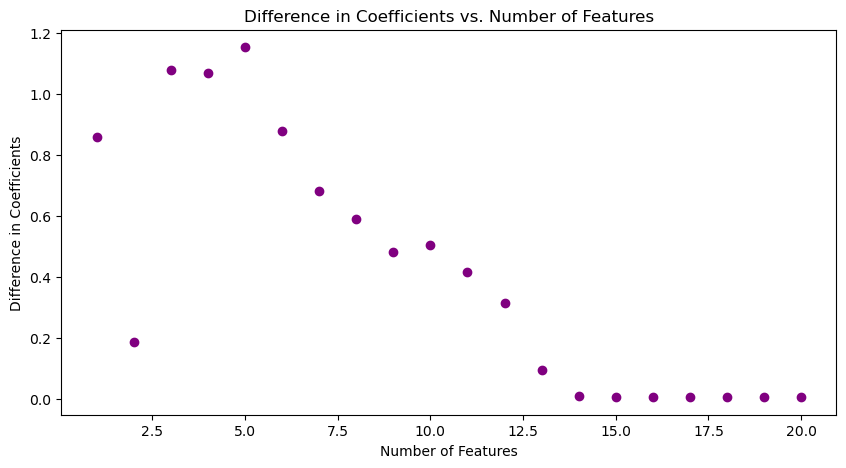

In [319]:
plt.figure(figsize = (10, 5))
plt.scatter(np.arange(1, 21), final_diff, color = 'purple')
plt.xlabel('Number of Features')
plt.ylabel('Difference in Coefficients')
plt.title('Difference in Coefficients vs. Number of Features')
plt.show()

# Question 11 Section 6.6

We will now try to predict per capita crime rate in the Boston data
set.

a) Try out some of the regression methods explored in this chapter,
such as best subset selection, the lasso, ridge regression, and
PCR. Present and discuss results for the approaches that you
consider.


In [226]:
#loading in the data
boston_df = pd.read_csv('../Data/Boston.csv', index_col = 0)
boston_df.dropna(inplace=True)

In [242]:
boston_df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [265]:
predictor = 'crim'
X_boston, Y_boston = boston_df.drop(predictor, axis=1), boston_df[predictor]

In [241]:
X.head()

,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
1,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
2,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
3,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
4,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
5,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [243]:
lambdas = 10**np.linspace (8, -2, 100)/Y.std()

In [247]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [253]:
from sklearn.linear_model import Ridge

In [266]:
X_train_boston, X_test_boston, Y_train_boston, Y_test_boston = train_test_split(X_boston, 
                                                                                Y_boston, 
                                                                                test_size=0.2, 
                                                                                random_state=42)

In [295]:
#Feature Selection

# Run forward stepwise selection
best_models_fs_boston = forward_stepwise_selection(X_train_boston, Y_train_boston.values)

# Extract number of features and training MSEs
num_features_fs_boston = list(range(1, len(X_train_boston.columns) + 1))
train_mse_fs_boston = [mse for _, mse, _ in best_models_fs_boston]

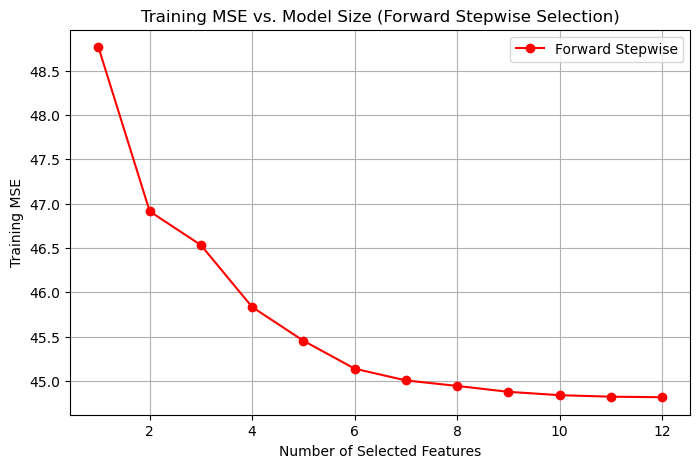

In [297]:
# Plot training MSE vs. number of features
plt.figure(figsize=(8, 5))
plt.plot(num_features_fs_boston, train_mse_fs_boston, marker='o', linestyle='-', color='r', label="Forward Stepwise")
plt.xlabel("Number of Selected Features")
plt.ylabel("Training MSE")
plt.title("Training MSE vs. Model Size (Forward Stepwise Selection)")
#plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

In [325]:
X_test_boston1 = sm.add_constant(X_test_boston)

y_pred = best_models_fs_boston[-1][-1].predict(X_test_boston1)



In [330]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [336]:
summarize(best_models_fs_boston[-1][-1])

,coef,std err,t,P>|t|
const,15.7270,8.215,1.914,0.056
rad,0.6387,0.105,6.058,0.000
medv,-0.2522,0.070,-3.600,0.000
dis,-1.0300,0.337,-3.056,0.002
zn,0.0439,0.023,1.908,0.057
nox,-11.7483,6.187,-1.899,0.058
ptratio,-0.3307,0.216,-1.533,0.126
rm,0.6899,0.728,0.948,0.344
tax,-0.0036,0.006,-0.592,0.554
chas,-1.0304,1.387,-0.743,0.458


In [331]:
print(mean_squared_error(Y_test_boston, y_pred))
print(mean_absolute_error(Y_test_boston, y_pred))
print(r2_score(Y_test_boston, y_pred))

304050.42849418806
514.3308192236882
-5517.137121977846


In [278]:
#Ridge Method

ridge = Ridge(fit_intercept = True)
scaler = StandardScaler(with_mean =True , with_std =True)
pipe = Pipeline (steps =[( 'scaler', scaler), ('ridge', ridge)])

#using validation method
validation = skm.ShuffleSplit (n_splits =1,
                                test_size = 0.2 ,
                                random_state =0)

param_grid = {'ridge__alpha': lambdas}

grid = skm.GridSearchCV ( pipe ,
                          param_grid ,
                          scoring='neg_mean_squared_error', 
                          cv=validation)

In [279]:
grid.fit(X_train_boston, Y_train_boston)
best_lambda = grid.best_params_['ridge__alpha']
best_ridge_model = grid.best_estimator_

In [335]:
#checking the coefficients of the ridge fitting
best_ridge_model.named_steps['ridge'].coef_

array([ 1.01411296, -0.1521308 , -0.26597555, -1.38107037,  0.48887146,
        0.26762266, -2.19249954,  5.47905177, -0.6039842 , -0.73610441,
        0.25088802, -2.35057518])

Text(0, 0.5, 'Cross - validated MSE ')

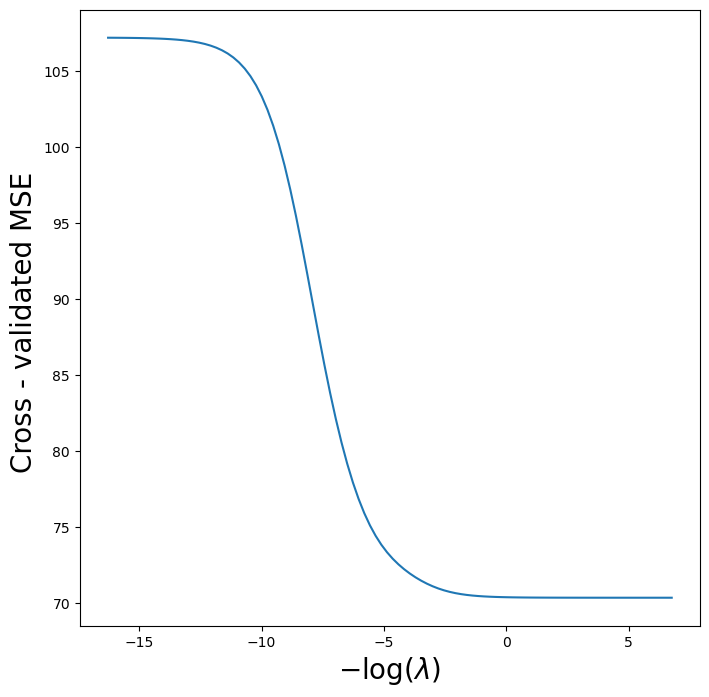

In [288]:
ridge_fig , ax = plt.subplots (figsize =(8 ,8))
ax.errorbar (-np.log(lambdas),
-grid.cv_results_['mean_test_score'],
yerr=grid.cv_results_ ['std_test_score']/np.sqrt(K))
ax. set_xlabel (r'$-\log (\lambda)$', fontsize =20)
ax. set_ylabel ('Cross - validated MSE ', fontsize =20)

In [ ]:
#using 
grid = skm. GridSearchCV(pipe ,
                            param_grid ,
                            cv=kfold ,
                            scoring='neg_mean_squared_error ')
grid.fit(X, Y)
grid.best_params_ ['ridge__alpha ']
grid.best_estimator_

In [289]:
from sklearn.linear_model import Lasso

In [292]:
#Lasso Method

lassoCV = Lasso(fit_intercept = True)
scaler = StandardScaler(with_mean =True , with_std =True)

pipeCV = Pipeline (steps =[( 'scaler', scaler), ('lasso', lassoCV)])

param_grid_lasso = {'lasso__alpha': lambdas}
validation = skm.ShuffleSplit (n_splits =1,
                                test_size = 0.2 ,
                                random_state =0)
grid = skm.GridSearchCV ( pipeCV,
                          param_grid_lasso ,
                          scoring='neg_mean_squared_error', 
                          cv=validation)

grid.fit(X_train_boston, Y_train_boston)
best_alpha = grid.best_params_['lasso__alpha']
best_lasso_model = grid.best_estimator_

In [334]:
#Seeing the Lasso Coefficients
best_lasso_model.named_steps['lasso'].coef_

array([ 0.95989322, -0.16827101, -0.25746258, -1.29174107,  0.45796159,
        0.24258048, -2.09751618,  5.30614533, -0.4248134 , -0.69371192,
        0.25290167, -2.26517059])

Text(0, 0.5, 'Cross - validated MSE ')

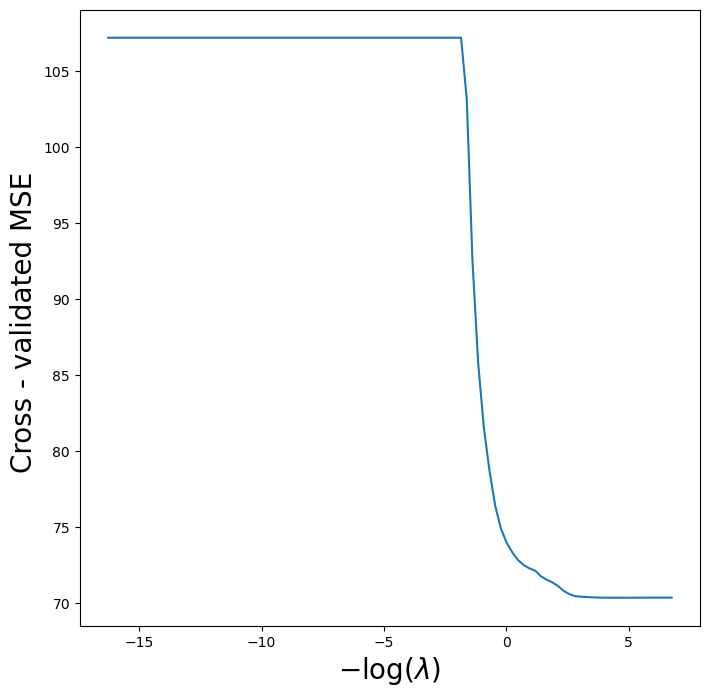

In [ ]:
lasso_fig , ax = plt.subplots (figsize =(8 ,8))

ax.errorbar (-np.log(lambdas),
-grid.cv_results_['mean_test_score'],
yerr=grid.cv_results_ ['std_test_score']/np.sqrt(K))
ax. set_xlabel (r'$-\log (\lambda)$', fontsize =20)
ax. set_ylabel ('Cross - validated MSE ', fontsize =20)

In [338]:
y_pred_lasso = best_lasso_model.predict(X_test_boston)

In [339]:
print(mean_squared_error(Y_test_boston, y_pred_lasso))
print(mean_absolute_error(Y_test_boston, y_pred_lasso))
print(r2_score(Y_test_boston, y_pred_lasso))

25.471136545391975
2.8486319894250416
0.5377305507965082


In [340]:
y_pred_ridge = best_ridge_model.predict(X_test_boston)

In [341]:
print(mean_squared_error(Y_test_boston, y_pred_ridge))
print(mean_absolute_error(Y_test_boston, y_pred_ridge))
print(r2_score(Y_test_boston, y_pred_ridge))

25.4686799203408
2.86262819234754
0.5377751354858205


b) Propose a model (or set of models) that seem to perform well on
this data set, and justify your answer. Make sure that you are
evaluating model performance using validation set error, cross-
validation, or some other reasonable alternative, as opposed to
using training error


From looking at the RME it seems like there are ridge and Lasso models that tend to give the same amount of MSE errors for their best fitting models and so I would choose one of them over the Feature selected one due to the fact that the predictions for the unseen data is not that good as it produced a negative $R^2$ implying the models is not doing a good job on new data. The ridge and lasso did really well on the unseen data and so I would go with them and it does look like for both ridge and Lasso models it did include all the features as there is no feature in the model that is set to zero or a very small value. 

c) Does your chosen model involve all of the features in the data
set? Why or why not?

In this scenario yes, the best fit model seems to have all the features included in it and that is most likely because to some extent each feature provides something to leverage in the prediction and so there is no feature that gets set to zero as that would imply that feature has little to no predictive power.